<a href="https://colab.research.google.com/github/alviglio/AlbJupyters/blob/main/SivaGuenterPeterBook/Chapter02_daily_water_balance_figure217.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2: Daily Water-Balance Model, Weekly Fluxes, Irrigation and Drainage

This notebook builds a small conceptual hydrological model that runs at a **daily time step** and then aggregates the results to **weekly values** for plotting.

The example is designed to reproduce, in a simplified and editable way, the kind of conceptual figure shown in Chapter 2 for humid catchments with drainage and arid catchments with irrigation.

The main water-balance equation is

$$
S_{t+1} = S_t + P_t - E_t - Q_t - Q_{d,t} + I_t
$$

where:

- $S$ is catchment water storage;
- $P$ is precipitation;
- $E$ is actual evapotranspiration;
- $Q$ is natural runoff;
- $Q_d$ is artificial drainage;
- $I$ is irrigation.

The model is deliberately simple. Its purpose is not calibration, but understanding. We use it to explore how runoff seasonality can emerge from storage, nonlinear flux laws, climate phase shifts, drainage, and irrigation.

## 1. Learning goals

By the end of this notebook, you should be able to:

1. write a simple catchment water-balance model at a daily time step;
2. distinguish between **fluxes** and **storages**;
3. explain why daily fluxes are summed, but storage is averaged or sampled, when aggregating to weekly values;
4. describe how nonlinear runoff and evapotranspiration functions depend on storage;
5. explain why humid catchments may need drainage and arid catchments may need irrigation;
6. change model parameters and interpret their effect on the plotted hydroclimatic cycles.

A central message is that seasonal runoff is not only a reflection of precipitation seasonality. It also depends on how catchments store water, how fast they release it, and whether water demand is in phase or out of phase with water supply.

## 2. Setup

We use only base R. The notebook should therefore run in a standard R runtime in Google Colab.

In Colab, use:

```text
Runtime → Change runtime type → R
```

In [1]:
# Plot size for Colab/Jupyter output
options(repr.plot.width = 14, repr.plot.height = 10)

# Color palette used throughout the notebook
col_P  <- "#0072B2"  # precipitation
col_EP <- "#F8766D"  # potential evapotranspiration
col_E  <- "#E69F00"  # actual evapotranspiration
col_Q  <- "#984EA3"  # runoff
col_M  <- "#66A61E"  # management: drainage or irrigation
col_S  <- "#56B4E9"  # storage

# A small helper used to keep the model numerically safe
rescale_outflows_if_needed <- function(outflows, available_water) {
  total_out <- sum(outflows)

  if (total_out > available_water && total_out > 0) {
    outflows <- outflows * available_water / total_out
  }

  outflows
}

## 3. Seasonal climate forcing

We first create idealized daily time series of precipitation $P$ and potential evapotranspiration $E_P$.

The time series are sinusoidal. This makes the model easy to interpret:

- in a **humid** case, precipitation is generally larger than potential evapotranspiration;
- in an **arid** case, potential evapotranspiration is generally larger than precipitation;
- by changing the timing of the peaks, we can make $P$ and $E_P$ either **in phase** or **out of phase**.

We use 364 days per year rather than 365. This is a practical modelling choice for a teaching example: 364 days equals exactly 52 weeks, so weekly aggregation does not create a short final week.

In [2]:
make_forcing <- function(
    n_years = 2,
    climate = "humid",
    phase = "out_of_phase"
) {
  n_days <- 364 * n_years
  day <- 1:n_days

  day_of_year <- ((day - 1) %% 364) + 1
  week <- ceiling(day / 7)
  week_of_year <- ceiling(day_of_year / 7)

  # Peak timing in day-of-year units
  # P_peak_day = 20 means precipitation peaks in winter.
  # EP_peak_day = 200 means potential evapotranspiration peaks in summer.
  if (phase == "out_of_phase") {
    P_peak_day <- 20
    EP_peak_day <- 200
  } else if (phase == "in_phase") {
    P_peak_day <- 200
    EP_peak_day <- 200
  } else {
    stop("phase must be 'out_of_phase' or 'in_phase'")
  }

  if (climate == "humid") {
    P_mean <- 4.0
    P_amp <- 3.0
    EP_mean <- 2.5
    EP_amp <- 2.0
  } else if (climate == "arid") {
    P_mean <- 1.5
    P_amp <- 1.2
    EP_mean <- 4.0
    EP_amp <- 3.0
  } else {
    stop("climate must be 'humid' or 'arid'")
  }

  P <- P_mean + P_amp * cos(2 * pi * (day_of_year - P_peak_day) / 364)
  EP <- EP_mean + EP_amp * cos(2 * pi * (day_of_year - EP_peak_day) / 364)

  P <- pmax(P, 0)
  EP <- pmax(EP, 0)

  data.frame(
    day = day,
    week = week,
    day_of_year = day_of_year,
    week_of_year = week_of_year,
    P = P,
    EP = EP
  )
}

### Inspect the forcing data

Before building a model, it is always useful to look at the inputs. Here we compare humid and arid climates, both with precipitation and potential evapotranspiration out of phase.

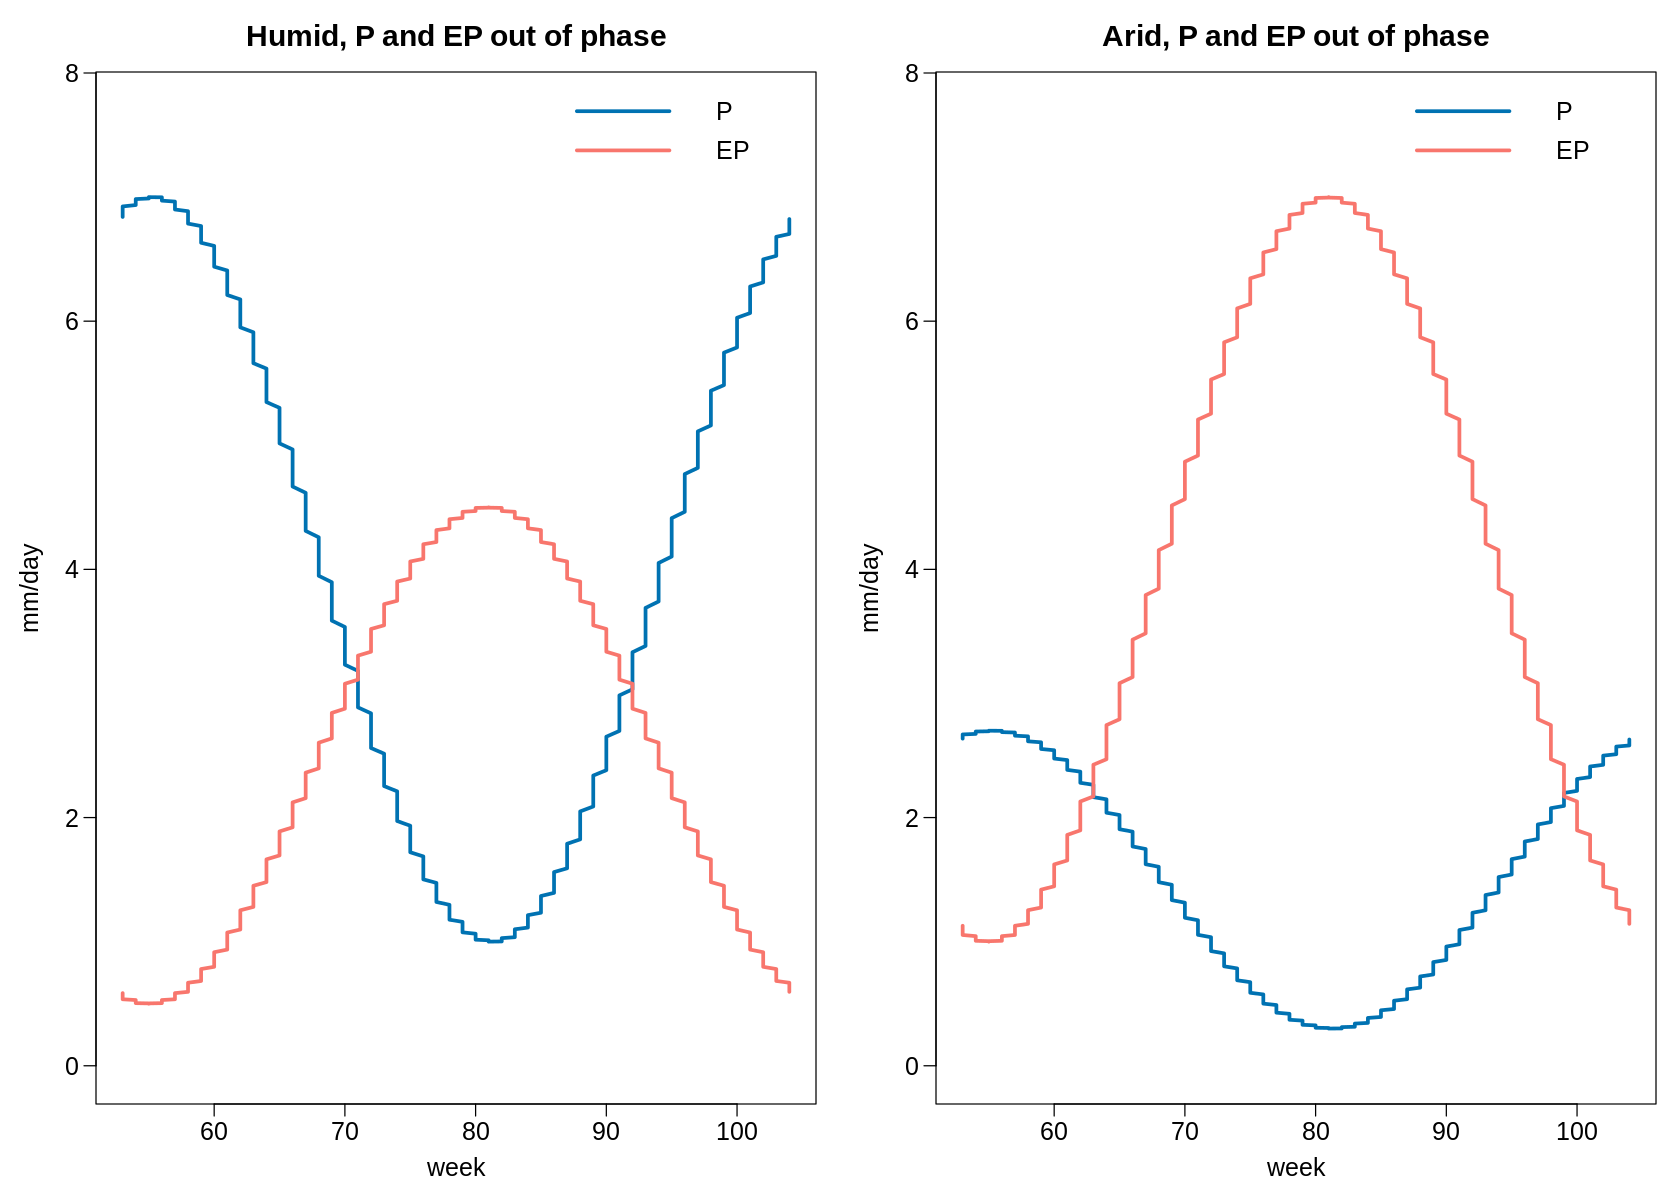

In [3]:
humid_forcing <- make_forcing(n_years = 2, climate = "humid", phase = "out_of_phase")
arid_forcing  <- make_forcing(n_years = 2, climate = "arid",  phase = "out_of_phase")

# Plot only the second year, so the first year can serve as spin-up in later figures.
plot_forcing <- function(forcing, title = "") {
  x <- forcing[forcing$week > 52, ]

  plot(x$week, x$P, type = "l", lwd = 3, col = col_P,
       xlab = "week", ylab = "mm/day", main = title,
       ylim = c(0, max(c(x$P, x$EP)) * 1.1))
  lines(x$week, x$EP, lwd = 3, col = col_EP)
  legend("topright", legend = c("P", "EP"), col = c(col_P, col_EP),
         lty = 1, lwd = 3, bty = "n")
}

layout(matrix(1:2, ncol = 2))
par(ps = 15, mar = c(4, 4, 3, 1), mgp = c(2.2, 0.7, 0), las = 1)
plot_forcing(humid_forcing, "Humid, P and EP out of phase")
plot_forcing(arid_forcing, "Arid, P and EP out of phase")

## 4. The daily water-balance model

The model has one water storage $S$. At each daily step:

1. precipitation and irrigation add water to storage;
2. runoff $Q$ removes water horizontally;
3. evapotranspiration $E$ removes water vertically;
4. drainage, if active, removes additional water when storage is high.

The nonlinear flux laws are:

$$
Q(S) = Q_0 \left(\frac{S}{S_b}\right)^b
$$

$$
E(S) = E_P(t) \left(\frac{S}{S_b}\right)^d
$$

The exponents control the shape of the response:

- larger runoff exponent: runoff increases more sharply when storage is high;
- evapotranspiration exponent below 1: plants can still access water efficiently when storage is low;
- evapotranspiration exponent above 1: evaporation is strongly limited at low storage.

We also enforce a basic physical rule: total outflow cannot exceed the water available in the store during the time step.

In [4]:
simulate_water_balance <- function(
    P,
    EP,
    Q0,
    Sb,
    b_Q,
    d_E,
    S0,
    Smax = Inf,

    # Artificial drainage
    drainage = FALSE,
    S_drain = Sb,
    k_drain = 0,

    # Irrigation
    irrigation = FALSE,
    S_irrig = 0.5 * Sb,
    Imax = 0,
    irrig_start_week = 1,
    irrig_end_week = 52
) {

  n <- length(P)

  if (length(EP) != n) {
    stop("P and EP must have the same length.")
  }

  S <- rep(NA, n + 1)
  Q <- rep(NA, n)
  E <- rep(NA, n)
  Qd <- rep(0, n)
  Pi <- rep(0, n)

  S[1] <- S0

  day <- 1:n
  week <- ceiling(day / 7)
  week_of_year <- ((week - 1) %% 52) + 1

  for (t in 1:n) {

    # ------------------------------------------------------
    # Irrigation rule
    # ------------------------------------------------------
    # Irrigation is added when storage is below a target,
    # but only during the selected irrigation season.

    if (
      irrigation &&
      week_of_year[t] >= irrig_start_week &&
      week_of_year[t] <= irrig_end_week
    ) {
      Pi[t] <- min(Imax, max(S_irrig - S[t], 0))
    }

    # Water available after external inputs
    S_available <- S[t] + P[t] + Pi[t]
    relS <- max(S_available / Sb, 0)

    # ------------------------------------------------------
    # Natural nonlinear fluxes
    # ------------------------------------------------------
    Q_potential <- Q0 * relS^b_Q
    E_potential <- EP[t] * pmin(relS, 1)^d_E

    # ------------------------------------------------------
    # Drainage rule
    # ------------------------------------------------------
    # Drainage is activated only when storage is above a threshold.

    if (drainage) {
      Qd[t] <- k_drain * max(S_available - S_drain, 0)
    }

    # ------------------------------------------------------
    # Physical constraint: outflows cannot exceed available water
    # ------------------------------------------------------
    out <- rescale_outflows_if_needed(
      c(Q_potential, E_potential, Qd[t]),
      S_available
    )

    Q[t] <- out[1]
    E[t] <- out[2]
    Qd[t] <- out[3]

    # ------------------------------------------------------
    # Storage update
    # ------------------------------------------------------
    S[t + 1] <- S_available - Q[t] - E[t] - Qd[t]
    S[t + 1] <- max(0, min(S[t + 1], Smax))
  }

  data.frame(
    day = day,
    week = week,
    week_of_year = week_of_year,
    P = P,
    EP = EP,
    E = E,
    Q = Q,
    Qd = Qd,
    Pi = Pi,
    S = S[-1]
  )
}

## 5. From daily to weekly values

The model runs daily, but the conceptual figure is easier to read at weekly resolution.

This is the most important aggregation rule:

- **fluxes** such as $P$, $E_P$, $E$, $Q$, drainage, and irrigation are summed over each week;
- **storage** $S$ is not summed, because storage is a state variable, not a flux.

For storage, we use the end-of-week value. This makes the weekly storage curve look like the model trajectory sampled every seven days.

If we summed storage over a week, the units would become strange and physically misleading. For example, 100 mm of storage for seven days is not 700 mm of storage in the same sense that 2 mm/day of rainfall for seven days is 14 mm/week.

In [5]:
to_weekly <- function(x) {

  weekly_fluxes <- aggregate(
    cbind(P, EP, E, Q, Qd, Pi) ~ week,
    data = x,
    FUN = sum
  )

  weekly_storage <- aggregate(
    S ~ week,
    data = x,
    FUN = function(z) z[length(z)]
  )

  merge(weekly_fluxes, weekly_storage, by = "week")
}

## 6. Plotting function

The figure shows weekly fluxes in mm/week and storage as $S/10$, so it can be plotted on the same axis as the fluxes.

The storage scaling is only for visualization. It does not change the model.

In [6]:
plot_water_balance_panel <- function(
    x,
    title = "",
    management = c("Qd", "Pi"),
    xlim = c(53, 104),
    ylim = c(0, 80)
) {

  management <- match.arg(management)

  plot(
    x$week, x$P,
    type = "n",
    xlim = xlim,
    ylim = ylim,
    xlab = "week",
    ylab = "weekly fluxes (mm/week), storage S/10",
    main = title
  )

  grid()

  lines(x$week, x$P,  col = col_P,  lwd = 3)
  lines(x$week, x$EP, col = col_EP, lwd = 3)
  points(x$week, x$E, pch = 4, col = col_E, lwd = 2)
  lines(x$week, x$Q, col = col_Q, lwd = 3)

  if (management == "Qd") {
    lines(x$week, x$Qd, col = col_M, lwd = 3)
    management_label <- "Qd"
  } else {
    lines(x$week, x$Pi, col = col_M, lwd = 3)
    management_label <- "Pi"
  }

  points(
    x$week, x$S / 10,
    pch = 21,
    col = col_S,
    bg = "white",
    lwd = 2
  )

  legend(
    "topright",
    legend = c("P", "EP", "E", "Q", management_label, "S/10"),
    col = c(col_P, col_EP, col_E, col_Q, col_M, col_S),
    lty = c(1, 1, NA, 1, 1, NA),
    pch = c(NA, NA, 4, NA, NA, 21),
    pt.bg = c(NA, NA, NA, NA, NA, "white"),
    lwd = 3,
    bty = "n",
    cex = 0.9
  )
}

## 7. Four scenarios

We now run four scenarios:

1. **Arid climate, no irrigation**: water demand is high and storage can become low.
2. **Humid climate, no drainage**: water is abundant and storage can remain high.
3. **Humid climate with drainage**: excess storage is removed when storage exceeds a threshold.
4. **Arid climate with irrigation**: water is added when storage falls below a target.

The first model year is used as spin-up. The plots focus on weeks 53–104, which correspond to the second model year.

In [7]:
# Generate two years of daily forcing.
humid_forcing <- make_forcing(n_years = 2, climate = "humid", phase = "out_of_phase")
arid_forcing  <- make_forcing(n_years = 2, climate = "arid",  phase = "out_of_phase")

# 1. Arid climate, no irrigation
arid_no_irrigation <- simulate_water_balance(
  P = arid_forcing$P,
  EP = arid_forcing$EP,
  Q0 = 8 / 7,
  Sb = 350,
  b_Q = 3.0,
  d_E = 0.6,
  S0 = 330,
  irrigation = FALSE,
  drainage = FALSE
)

# 2. Humid climate, no artificial drainage
humid_no_drainage <- simulate_water_balance(
  P = humid_forcing$P,
  EP = humid_forcing$EP,
  Q0 = 42 / 7,
  Sb = 500,
  b_Q = 3.0,
  d_E = 0.4,
  S0 = 650,
  drainage = FALSE,
  irrigation = FALSE
)

# 3. Humid climate, with artificial drainage
humid_drainage <- simulate_water_balance(
  P = humid_forcing$P,
  EP = humid_forcing$EP,
  Q0 = 30 / 7,
  Sb = 500,
  b_Q = 3.0,
  d_E = 0.4,
  S0 = 600,
  drainage = TRUE,
  S_drain = 580,
  k_drain = 0.18,
  irrigation = FALSE
)

# 4. Arid climate, with irrigation
arid_irrigation <- simulate_water_balance(
  P = arid_forcing$P,
  EP = arid_forcing$EP,
  Q0 = 8 / 7,
  Sb = 350,
  b_Q = 3.0,
  d_E = 0.6,
  S0 = 350,
  irrigation = TRUE,
  S_irrig = 200,
  Imax = 5,
  irrig_start_week = 8,
  irrig_end_week = 28,
  drainage = FALSE
)

# Aggregate daily values to weekly values
w_arid_no_irrigation <- to_weekly(arid_no_irrigation)
w_humid_no_drainage <- to_weekly(humid_no_drainage)
w_humid_drainage <- to_weekly(humid_drainage)
w_arid_irrigation <- to_weekly(arid_irrigation)

## 8. Figure 2.17-style conceptual result

This figure shows how management changes the seasonal water balance.

In the humid case, storage is high during the wet period. Drainage removes water when storage exceeds a threshold. This increases the managed outflow during wet periods and reduces excessive storage.

In the arid case, storage becomes low during the dry or high-demand period. Irrigation adds water when storage falls below a target level. This supports evapotranspiration and changes the seasonal storage trajectory.

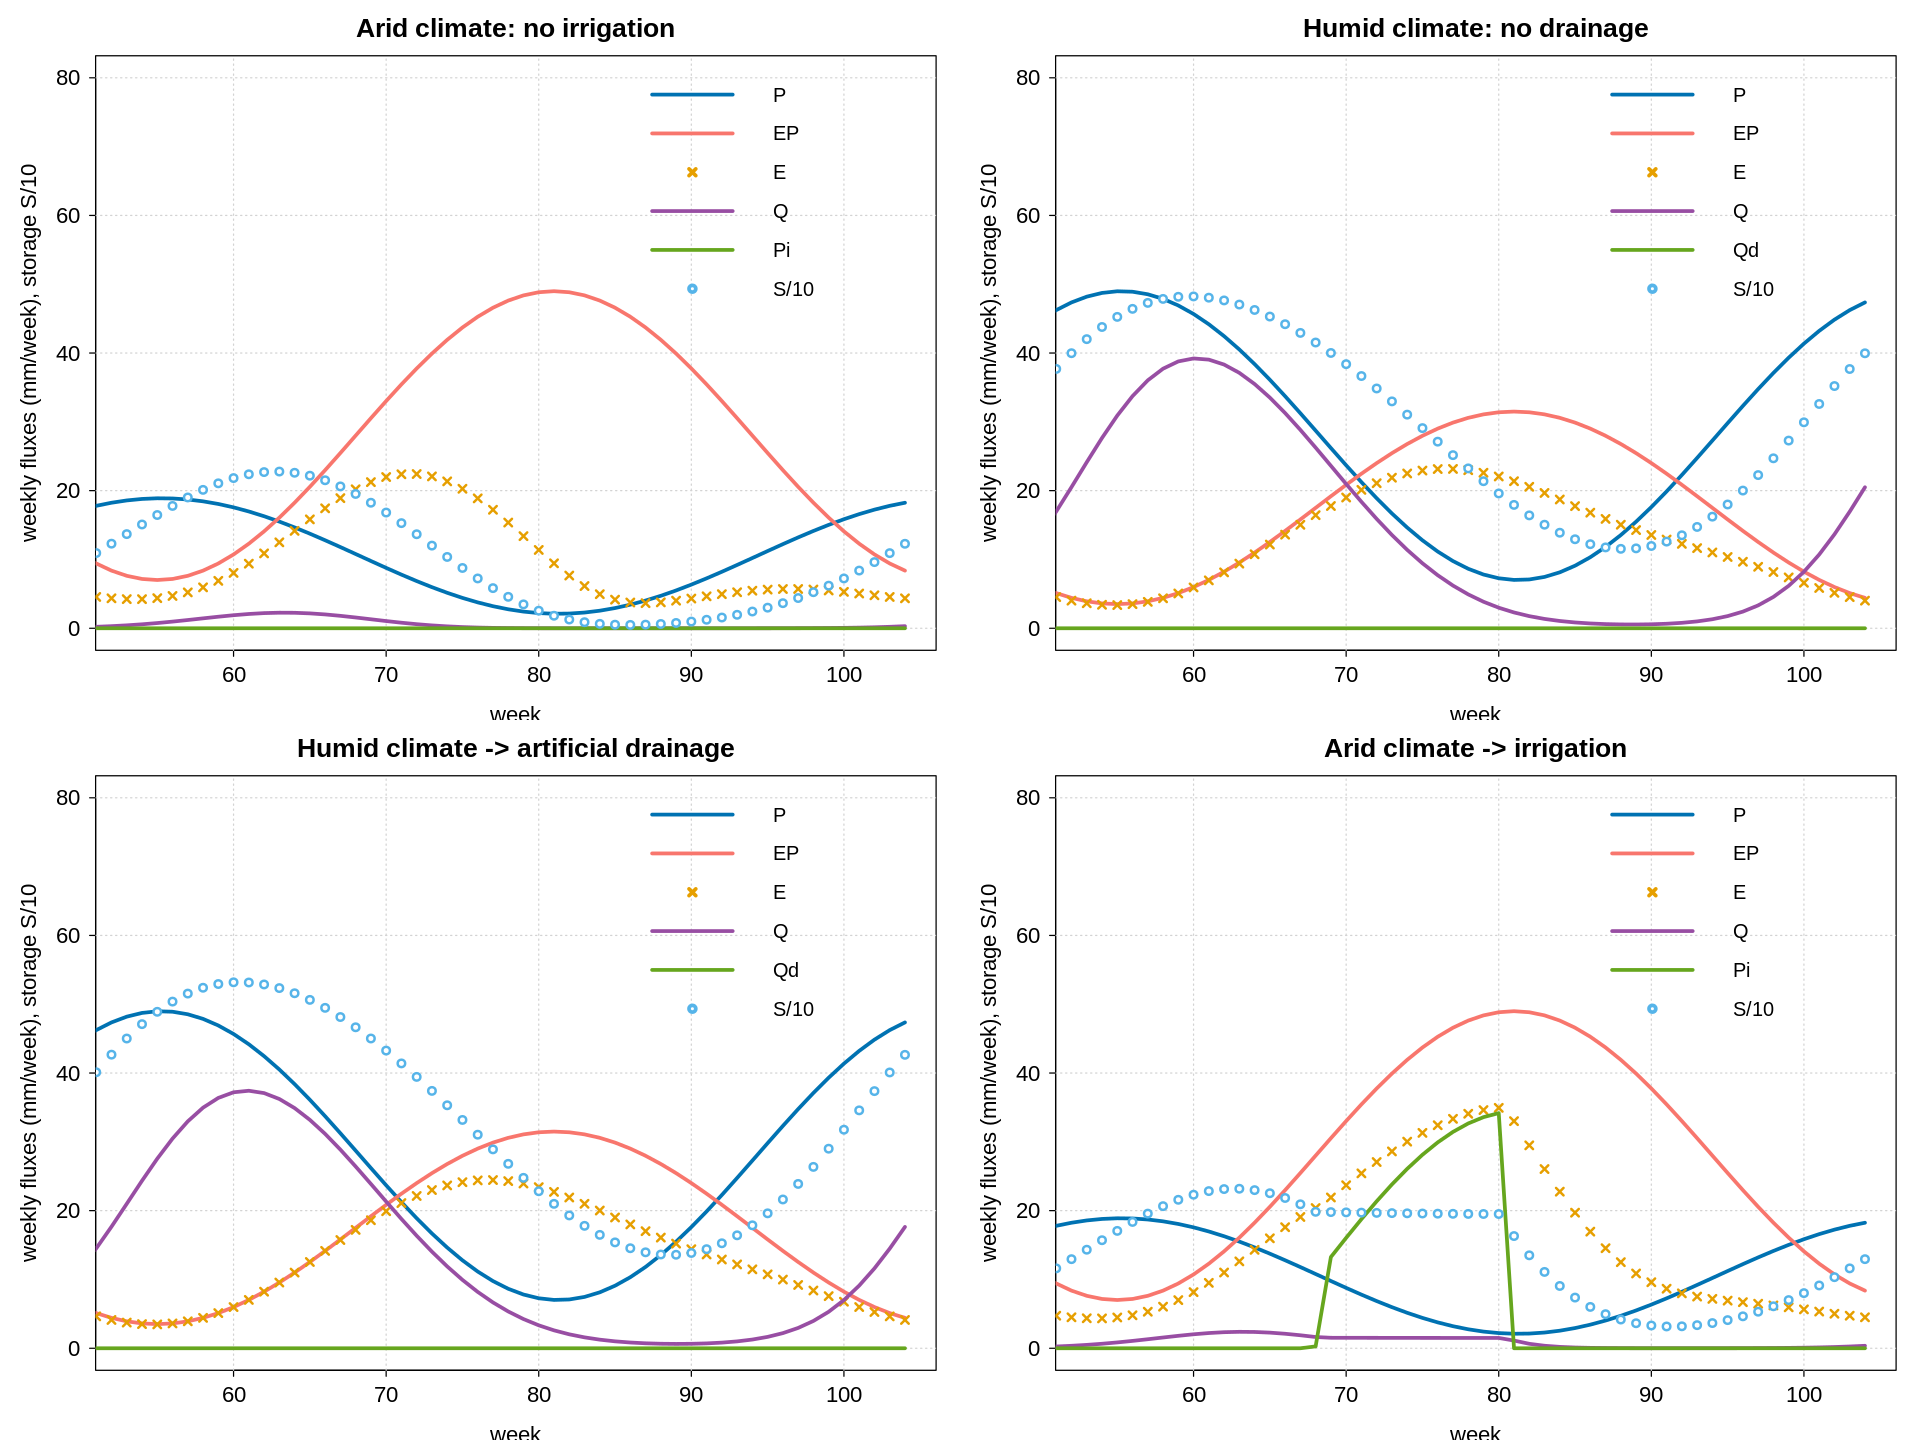

In [8]:
options(repr.plot.width = 16, repr.plot.height = 12)

layout(matrix(1:4, nrow = 2, byrow = TRUE))

par(
  ps = 16,
  mar = c(3.5, 4.8, 2.8, 1.2),
  mgp = c(2.8, 0.8, 0),
  tcl = -0.3,
  las = 1
)

plot_water_balance_panel(
  w_arid_no_irrigation,
  title = "Arid climate: no irrigation",
  management = "Pi"
)

plot_water_balance_panel(
  w_humid_no_drainage,
  title = "Humid climate: no drainage",
  management = "Qd"
)

plot_water_balance_panel(
  w_humid_drainage,
  title = "Humid climate -> artificial drainage",
  management = "Qd"
)

plot_water_balance_panel(
  w_arid_irrigation,
  title = "Arid climate -> irrigation",
  management = "Pi"
)

## 9. What to look for in the figure

Use the figure to answer the following questions.

### Humid catchment

1. When is storage highest?
2. When is runoff largest?
3. How does artificial drainage change the timing and magnitude of outflow?
4. Does drainage mainly affect wet periods or dry periods?

### Arid catchment

1. When is storage lowest?
2. When is potential evapotranspiration highest?
3. How does irrigation affect storage and actual evapotranspiration?
4. Why does irrigation appear during only part of the year?

### General interpretation

In both climates, storage acts as a buffer. It delays and reshapes the effect of climate drivers. The same precipitation time series can produce different runoff behavior depending on storage capacity, nonlinear response parameters, evapotranspiration demand, and human management.

## 10. Interactive controls for Colab

The following cell uses Colab form fields. In Google Colab, the annotations after `#@param` create sliders, checkboxes, and dropdown menus.

After changing a slider, re-run the cell and then re-run the model cell below it.

In [14]:
#@title Interactive scenario controls

climate_type <- "humid" #@param ["humid", "arid"]
phase_type <- "out_of_phase" #@param ["out_of_phase", "in_phase"]

use_drainage <- TRUE #@param {type:"boolean"}
use_irrigation <- FALSE #@param {type:"boolean"}

Q0_week <- 30 #@param {type:"slider", min:0, max:80, step:1}
Sb <- 500 #@param {type:"slider", min:50, max:1000, step:10}
b_Q <- 3 #@param {type:"slider", min:0.2, max:6, step:0.1}
d_E <- 0.5 #@param {type:"slider", min:0.1, max:3, step:0.1}
S0 <- 500 #@param {type:"slider", min:0, max:1000, step:10}

S_drain <- 580 #@param {type:"slider", min:0, max:1000, step:10}
k_drain <- 0.51 #@param {type:"slider", min:0, max:1, step:0.01}

S_irrig <- 200 #@param {type:"slider", min:0, max:1000, step:10}
Imax <- 5 #@param {type:"slider", min:0, max:30, step:0.5}
irrig_start_week <- 8 #@param {type:"slider", min:1, max:52, step:1}
irrig_end_week <- 28 #@param {type:"slider", min:1, max:52, step:1}

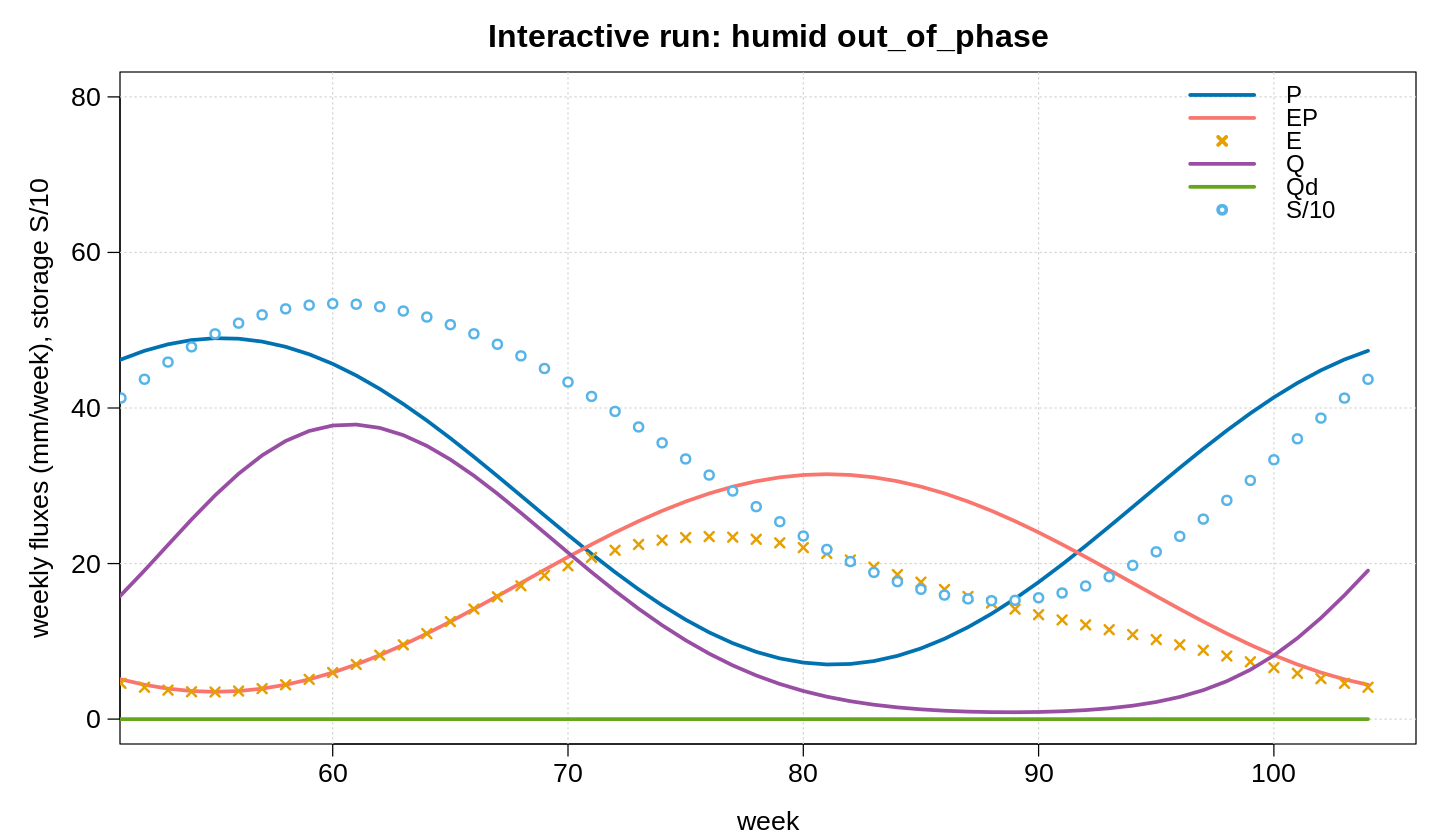

In [15]:
# Run the interactive scenario
interactive_forcing <- make_forcing(
  n_years = 2,
  climate = climate_type,
  phase = phase_type
)

interactive_run <- simulate_water_balance(
  P = interactive_forcing$P,
  EP = interactive_forcing$EP,
  Q0 = Q0_week / 7,
  Sb = Sb,
  b_Q = b_Q,
  d_E = d_E,
  S0 = S0,
  drainage = use_drainage,
  S_drain = S_drain,
  k_drain = k_drain,
  irrigation = use_irrigation,
  S_irrig = S_irrig,
  Imax = Imax,
  irrig_start_week = irrig_start_week,
  irrig_end_week = irrig_end_week
)

w_interactive <- to_weekly(interactive_run)

options(repr.plot.width = 12, repr.plot.height = 7)
par(ps = 16, mar = c(4, 5, 3, 1), mgp = c(2.8, 0.8, 0), las = 1)

management_to_show <- if (use_irrigation) "Pi" else "Qd"

plot_water_balance_panel(
  w_interactive,
  title = paste("Interactive run:", climate_type, phase_type),
  management = management_to_show
)

## 11. Parameter experiments

Try the following experiments.

### Experiment 1: make runoff more nonlinear

Increase `b_Q`. What happens to the runoff peak? Does runoff respond more strongly to high storage?

### Experiment 2: increase catchment storage capacity

Increase `Sb`. Does storage fluctuate more slowly? Does runoff become smoother?

### Experiment 3: turn on drainage in a humid catchment

Use:

```text
climate_type = humid
use_drainage = TRUE
use_irrigation = FALSE
```

Then lower `S_drain`. At what point does drainage become active for much of the year?

### Experiment 4: turn on irrigation in an arid catchment

Use:

```text
climate_type = arid
use_drainage = FALSE
use_irrigation = TRUE
```

Increase `S_irrig` or `Imax`. How do storage and actual evapotranspiration change?

### Experiment 5: compare in-phase and out-of-phase climates

Switch `phase_type` between `in_phase` and `out_of_phase`. Which case requires more storage to sustain evapotranspiration and runoff during dry periods?

## 12. Summary

This notebook used a simple daily model to show how seasonal runoff patterns can arise from storage and nonlinear fluxes.

The key ideas are:

- precipitation and potential evapotranspiration are climate drivers;
- storage delays and reshapes those climate signals;
- runoff and evapotranspiration depend on storage;
- nonlinear storage-flux relationships can amplify high-flow or low-flow behavior;
- weekly fluxes are obtained by summing daily fluxes;
- weekly storage is better represented by a sampled or average state, not a sum;
- drainage is a response to excess water in humid settings;
- irrigation is a response to water deficits in arid settings.

The model is intentionally simple, but it provides a useful laboratory for understanding the mechanisms behind seasonal runoff.